<a href="https://colab.research.google.com/github/Aliabbas7863/COVID-19-Data-Analysis/blob/main/code_19_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:


df = pd.read_csv("/content/country_wise_latest.csv")

print(df.head())
print(df.info())

  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04                35526            737   
1   

In [8]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(187, 15)
Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null

In [9]:
df.isnull().sum()

,0
Country/Region,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
New cases,0
New deaths,0
New recovered,0
Deaths / 100 Cases,0
Recovered / 100 Cases,0


In [10]:
country_cases = df.groupby("Country/Region")[["Confirmed","Deaths","Recovered"]].max()

print(country_cases.head())

                Confirmed  Deaths  Recovered
Country/Region                              
Afghanistan         36263    1269      25198
Albania              4880     144       2745
Algeria             27973    1163      18837
Andorra               907      52        803
Angola                950      41        242


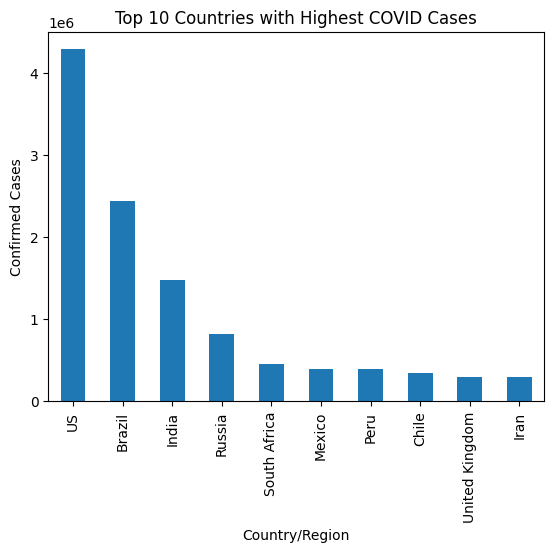

In [11]:
top10 = country_cases.sort_values("Confirmed", ascending=False).head(10)

top10["Confirmed"].plot(kind="bar")
plt.title("Top 10 Countries with Highest COVID Cases")
plt.ylabel("Confirmed Cases")
plt.show()

In [12]:
country_cases["Death Rate"] = (country_cases["Deaths"] / country_cases["Confirmed"]) * 100

country_cases.head()

,Confirmed,Deaths,Recovered,Death Rate
Country/Region,,,,
Afghanistan,36263,1269,25198,3.499435
Albania,4880,144,2745,2.950820
Algeria,27973,1163,18837,4.157581
Andorra,907,52,803,5.733186
Angola,950,41,242,4.315789


In [16]:
top_recovered = df.sort_values(by="Recovered", ascending=False).head(10)

print(top_recovered[["Country/Region","Recovered"]])

    Country/Region  Recovered
23          Brazil    1846641
173             US    1325804
79           India     951166
138         Russia     602249
35           Chile     319954
111         Mexico     303810
154   South Africa     274925
132           Peru     272547
81            Iran     255144
128       Pakistan     241026


In [17]:
region_cases = df.groupby("WHO Region")[["Confirmed","Deaths","Recovered"]].sum()

print(region_cases)

                       Confirmed  Deaths  Recovered
WHO Region                                         
Africa                    723207   12223     440645
Americas                 8839286  342732    4468616
Eastern Mediterranean    1490744   38339    1201400
Europe                   3299523  211144    1993723
South-East Asia          1835297   41349    1156933
Western Pacific           292428    8249     206770


In [18]:
total_confirmed = df["Confirmed"].sum()
total_deaths = df["Deaths"].sum()
total_recovered = df["Recovered"].sum()
total_active = df["Active"].sum()

print("Total Confirmed:", total_confirmed)
print("Total Deaths:", total_deaths)
print("Total Recovered:", total_recovered)
print("Total Active:", total_active)

Total Confirmed: 16480485
Total Deaths: 654036
Total Recovered: 9468087
Total Active: 6358362


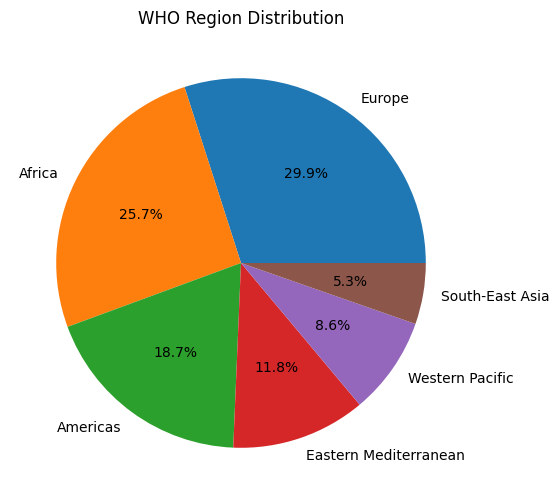

In [20]:
region_counts = df["WHO Region"].value_counts()

plt.figure(figsize=(8,6))
region_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("WHO Region Distribution")
plt.ylabel("")
plt.show()

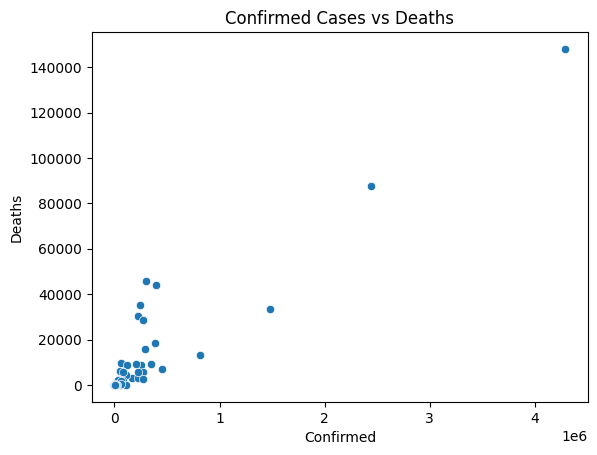

In [13]:
sns.scatterplot(data=country_cases, x="Confirmed", y="Deaths")
plt.title("Confirmed Cases vs Deaths")
plt.show()

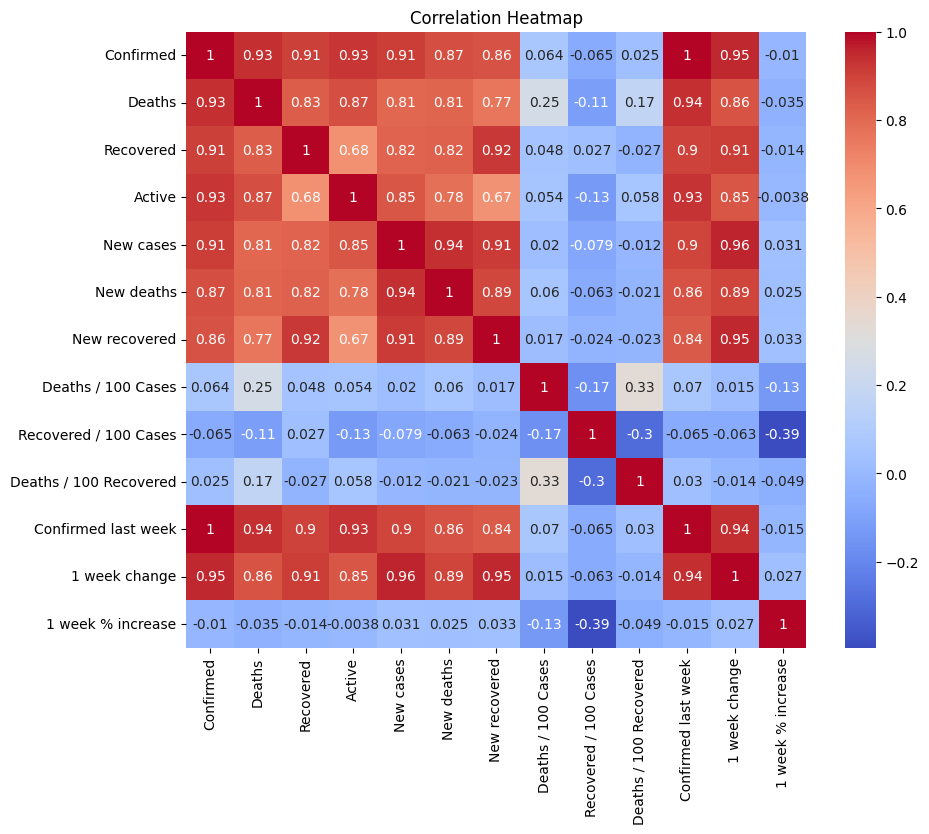

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [22]:
top_growth = df.sort_values(by="1 week % increase", ascending=False).head(10)

print(top_growth[["Country/Region","1 week % increase"]])

       Country/Region  1 week % increase
130  Papua New Guinea             226.32
63             Gambia             191.07
11            Bahamas             119.54
186          Zimbabwe              57.85
99              Libya              42.78
58           Ethiopia              42.52
22           Botswana              41.57
97            Lesotho              40.67
160          Suriname              37.44
41         Costa Rica              37.34
